# Global analysis
* UMAPs - single and double positive cells
* Barcharts for each label type for scANVI and Seurat

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_03/03b_thresholds"

In [5]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_03/03b_thresholds"

adata_path = input_dir / "adata-labeled.h5ad"

In [6]:
adata = sc.read_h5ad(adata_path)

In [28]:
adata.obs.seurat_class.value_counts()

seurat_class
Non-neuron    82560
Neuron        63591
Name: count, dtype: int64

In [7]:
# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos = dual

# Build a small table
df = pd.DataFrame(
    {
        "barcode": adata.obs.index,
        "seurat_label": adata.obs["seurat_labels"],
        "scanvi_label": adata.obs["scanvi_labels"],
        "sample_id": adata.obs["sample_id"],
        "confidence": adata.obs["confidence"],
        "EGFP_single": egfp_single.values,
        "dTom_single": dtom_single.values,
        "Dual_positive": dual_pos.values,
    }
)

# Summary
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
apeeemip-1,apeeemip-1,Vascular_endothelial_1,Vascular_endothelial_1,Middle
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
jkabbhfm-1,jkabbhfm-1,CGRP-Gamma,CGRP-Gamma,NaN


In [25]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    147013
True         23
Name: count, dtype: int64

In [8]:
import pandas as pd

# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos = dual

# Build dataframe
df = pd.DataFrame(
    {
        "barcode": adata.obs.index,
        "sample_id": adata.obs["sample_id"],
        "seurat_label": adata.obs["seurat_labels"],
        "scanvi_label": adata.obs["scanvi_labels"],
        "confidence": adata.obs["confidence"],
        "EGFP_single": egfp_single.values,
        "dTom_single": dtom_single.values,
        "Dual_positive": dual_pos.values,
    }
)

# Masks
dual_mask = df["Dual_positive"]
conf_mask = df["confidence"].notna()

# ------------------------------
# 1. Dual-positive WITH confidence
# ------------------------------
dual_with_conf = df[dual_mask & conf_mask]

# ------------------------------
# 2. Dual-positive WITHOUT confidence
# ------------------------------
dual_without_conf = df[dual_mask & ~conf_mask]

# ------------------------------
# 3. Confidence entries that ARE dual-positive
#    (same as #1)
# ------------------------------
conf_and_dual = dual_with_conf

# ------------------------------
# 4. Confidence entries that are NOT dual-positive
# ------------------------------
conf_not_dual = df[conf_mask & ~dual_mask]

In [23]:
# Dual-positive WITH confidence
print("=== Dual-positive WITH confidence ===")
display(
    dual_with_conf[
        ["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]
    ].reset_index(drop=True)
)
print(f"Total: {len(dual_with_conf)}\n")

# Dual-positive WITHOUT confidence
print("=== Dual-positive WITHOUT confidence ===")
display(
    dual_without_conf[
        ["barcode", "sample_id", "seurat_label", "scanvi_label"]
    ].reset_index(drop=True)
)
print(f"Total: {len(dual_without_conf)}\n")

=== Dual-positive WITH confidence ===


,barcode,sample_id,seurat_label,scanvi_label,confidence
0,apeeemip-1,TMA00304,Vascular_endothelial_1,Vascular_endothelial_1,Middle
1,bpoikicj-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
2,cbhmmeof-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
3,bmjgagok-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
4,ijnggkoc-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
5,llknggjo-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
6,llmfnafp-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
7,llmgffik-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
8,aefmnmje-1,TMA00311,CGRP-Gamma,CGRP-Gamma,High
9,akcoadof-1,TMA00305,CGRP-Gamma,CGRP-Gamma,High


Total: 17

=== Dual-positive WITHOUT confidence ===


,barcode,sample_id,seurat_label,scanvi_label
0,jjmnhibg-1,TMA00313,CGRP-Gamma,CGRP-Gamma
1,jkabbhfm-1,TMA00313,CGRP-Gamma,CGRP-Gamma
2,mklknhcg-1,TMA00311,CGRP-Gamma,CGRP-Gamma
3,ajnphbmj-1,TMA00310,CGRP-Gamma,CGRP-Gamma
4,eckajpnf-1,TMA00310,CGRP-Gamma,CGRP-Gamma
5,ebnfggjb-1,TMA00312,CGRP-Gamma,CGRP-Gamma


Total: 6



In [24]:
# === Confidence entries that ARE Dual-positive ===
print("=== Confidence entries that ARE Dual-positive ===")
display(
    conf_and_dual[
        ["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]
    ].reset_index(drop=True)
)
print(f"Total: {len(conf_and_dual)}\n")

# === Manual annotations that are NOT Dual-positive ===
print("=== Manual annotations that are NOT Dual-positive ===")
display(
    conf_not_dual[
        ["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]
    ].reset_index(drop=True)
)
print(f"Total: {len(conf_not_dual)}")

=== Confidence entries that ARE Dual-positive ===


,barcode,sample_id,seurat_label,scanvi_label,confidence
0,apeeemip-1,TMA00304,Vascular_endothelial_1,Vascular_endothelial_1,Middle
1,bpoikicj-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
2,cbhmmeof-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
3,bmjgagok-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
4,ijnggkoc-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
5,llknggjo-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
6,llmfnafp-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
7,llmgffik-1,TMA00306,CGRP-Gamma,CGRP-Gamma,High
8,aefmnmje-1,TMA00311,CGRP-Gamma,CGRP-Gamma,High
9,akcoadof-1,TMA00305,CGRP-Gamma,CGRP-Gamma,High


Total: 17

=== Manual annotations that are NOT Dual-positive ===


,barcode,sample_id,seurat_label,scanvi_label,confidence
0,agbmnepe-1,TMA00304,CGRP-Gamma,CGRP-Gamma,High
1,bcmkpnkd-1,TMA00311,CGRP-Alpha,CGRP-Alpha,Low
2,iidhhibl-1,TMA00311,CGRP-Gamma,CGRP-Gamma,Middle
3,aallcopa-1,TMA00303,CGRP-Gamma,CGRP-Gamma,Middle
4,acpnmbio-1,TMA00303,CGRP-Gamma,CGRP-Gamma,Middle


Total: 5


# UMAP

In [11]:
# Extract masks
egfp_hi = adata.obs["EGFP_Seq1_hi"].values
td_hi = adata.obs["dTomato_Seq2_hi"].values
dual_hi = adata.obs["EGFP_dTomato_dual_hi"].values

egfp_only = egfp_hi & ~td_hi
td_only = td_hi & ~egfp_hi

In [12]:
summary = pd.DataFrame(
    {
        "EGFP_only": [egfp_only.sum()],
        "dTomato_only": [td_only.sum()],
        "dual_high": [dual_hi.sum()],
        "any_positive": [(egfp_hi | td_hi).sum()],
    }
)
summary

,EGFP_only,dTomato_only,dual_high,any_positive
0,58,117,23,198


In [13]:
# Get umap coordinates and indices
umap = adata.obsm["X_umap"]

egfp_idx = np.where(egfp_only)[0]
td_idx = np.where(td_only)[0]
dual_idx = np.where(dual_hi)[0]

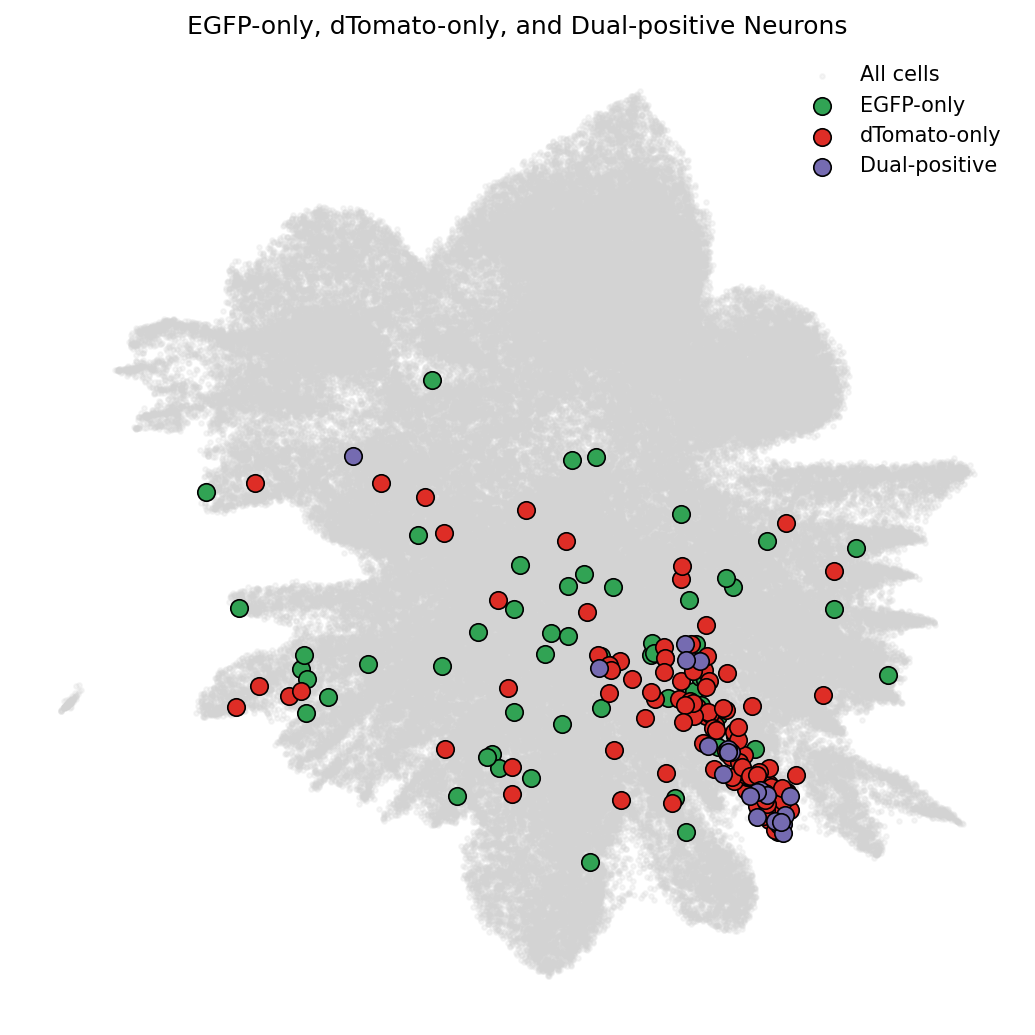

In [14]:
# plot
plt.figure(figsize=(7, 7), dpi=150)

# Background
plt.scatter(umap[:, 0], umap[:, 1], s=5, c="lightgray", alpha=0.20, label="All cells")

# EGFP-only (green)
plt.scatter(
    umap[egfp_idx, 0],
    umap[egfp_idx, 1],
    s=70,
    c="#31a354",
    edgecolors="black",
    linewidths=0.8,
    label="EGFP-only",
)

# dTomato-only (red)
plt.scatter(
    umap[td_idx, 0],
    umap[td_idx, 1],
    s=70,
    c="#de2d26",
    edgecolors="black",
    linewidths=0.8,
    label="dTomato-only",
)

# Dual positive (purple)
plt.scatter(
    umap[dual_idx, 0],
    umap[dual_idx, 1],
    s=70,
    c="#756bb1",
    edgecolors="black",
    linewidths=0.8,
    label="Dual-positive",
)

plt.title("EGFP-only, dTomato-only, and Dual-positive Neurons")
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

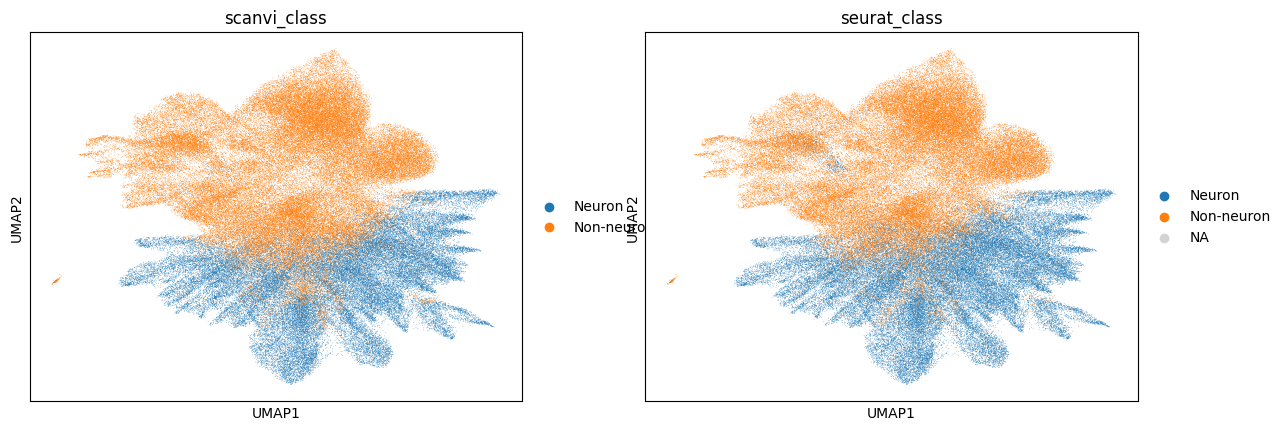

In [15]:
sc.pl.umap(adata, color=["scanvi_class", "seurat_class"])

# Single and double-positive distributions

## Bar plots

In [16]:
def plot_bar_from_labels(
    data, label_col, title, figsize=(6, 4), horizontal=False, color="steelblue"
):
    counts = data[label_col].value_counts()

    # Use seaborn style that *keeps* ticks
    sns.set_style("ticks")

    fig, ax = plt.subplots(figsize=figsize)

    # ---- Plot ----
    if horizontal:
        sns.barplot(
            y=counts.index, x=counts.values, color=color, edgecolor="black", ax=ax
        )
        ax.set_xlabel("Count", fontsize=10)
        ax.set_ylabel(label_col, fontsize=10)

        # integer ticks
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    else:
        sns.barplot(
            x=counts.index, y=counts.values, color=color, edgecolor="black", ax=ax
        )
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xlabel(label_col, fontsize=10)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ---- Make tick marks visible and nice ----
    ax.tick_params(
        axis="both", which="both", length=4, width=1, direction="out", labelsize=9
    )

    # Keep only bottom & left spines (clean aesthetic)
    sns.despine(ax=ax)

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

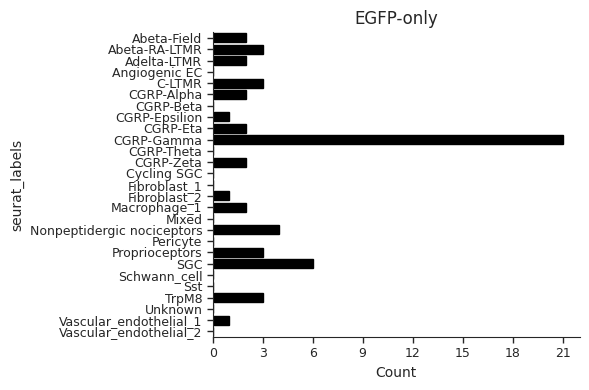

In [29]:
# EGFP-only — scANVI
# plot_bar_from_labels(
#    adata.obs[egfp_only],
#    label_col="scanvi_labels",
#    title="EGFP-only — scANVI Labels",
#    horizontal=True,
#    color="limegreen"
# )

# EGFP-only — Seurat
plot_bar_from_labels(
    adata.obs[egfp_only],
    label_col="seurat_labels",
    title="EGFP-only",
    horizontal=True,
    color="black",
)

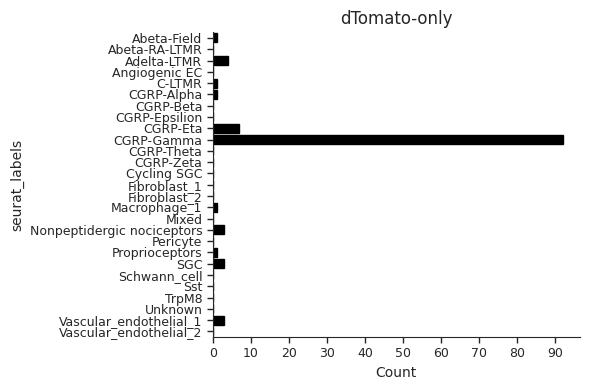

In [30]:
# dTomato-only: scANVI labels (bright red)
# plot_bar_from_labels(
#    adata.obs[td_only],
#    "scanvi_labels",
#    "dTomato-only Positive — scANVI Labels",
#    horizontal=True,
#    color="crimson"
# )

# dTomato-only: Seurat labels (bright red)
plot_bar_from_labels(
    adata.obs[td_only], "seurat_labels", "dTomato-only", horizontal=True, color="black"
)

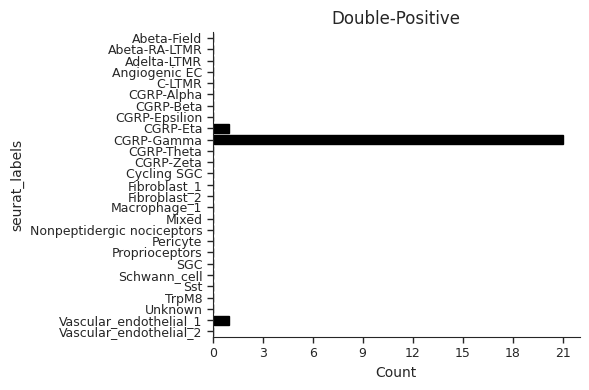

In [31]:
# Dual-positive: scANVI labels
# plot_bar_from_labels(
#    adata.obs[dual_hi],
#    "scanvi_labels",
#    "Dual-Positive — scANVI Labels",
#    horizontal=True,
#    color="black"
# )

# Dual-positive: Seurat labels (royalblue)
plot_bar_from_labels(
    adata.obs[dual_hi],
    "seurat_labels",
    "Double-Positive",
    horizontal=True,
    color="black",
)